In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# Load clean data
df = pd.read_csv("spark_spread_project/data/clean/merged_hourly.csv")
df["price_timestamp"] = pd.to_datetime(df["price_timestamp"])

# Spark spread
ETA              = 0.50
CARBON_INTENSITY = 0.35
df["spark_spread"] = (
    df["power_eur_mwh"]
    - (df["gas_eur_mwh"] / ETA)
    - (CARBON_INTENSITY * df["carbon_eur_tonne"])
)

# Regimes
conditions = [
    (df["price_timestamp"] < "2021-09-01"),
    (df["price_timestamp"] >= "2021-09-01") & (df["price_timestamp"] < "2023-01-01"),
    (df["price_timestamp"] >= "2023-01-01")
]
labels = ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]
df["regime"] = np.select(conditions, labels, default="C - Recovery")

print(f"Rows loaded : {len(df):,}")
print(f"Spread mean : {df['spark_spread'].mean():.2f} EUR/MWh")
print("Ready.")

Rows loaded : 26,280
Spread mean : -29.65 EUR/MWh
Ready.


In [2]:
# Rolling window — 720 hours = 30 days
WINDOW = 720

df["rolling_mean"] = df["spark_spread"].rolling(window=WINDOW, min_periods=24).mean()
df["rolling_std"]  = df["spark_spread"].rolling(window=WINDOW, min_periods=24).std()

# Z-score — how many standard deviations away from the rolling mean
df["z_score"] = (df["spark_spread"] - df["rolling_mean"]) / df["rolling_std"]

print("Rolling stats calculated.")
print(f"\nZ-score range:")
print(f"  Min  : {df['z_score'].min():.2f}")
print(f"  Max  : {df['z_score'].max():.2f}")
print(f"  Mean : {df['z_score'].mean():.4f}")
print(f"\nFirst non-null row:")
print(df[["price_timestamp","spark_spread","rolling_mean","rolling_std","z_score"]].dropna().head(1))

Rolling stats calculated.

Z-score range:
  Min  : -9.65
  Max  : 10.35
  Mean : -0.0123

First non-null row:
       price_timestamp  spark_spread  rolling_mean  rolling_std   z_score
23 2021-01-01 23:00:00       -1.9415      -5.22775     7.059051  0.465537


In [3]:
ENTRY_Z = 2.0    # enter trade when spread is 2σ away from mean
EXIT_Z  = 0.5    # exit trade when spread returns within 0.5σ of mean

# Generate raw signals
df["signal"] = 0
df.loc[df["z_score"] >  ENTRY_Z, "signal"] = -1   # Short
df.loc[df["z_score"] < -ENTRY_Z, "signal"] =  1   # Long

# Exit logic — once in a trade, hold until z-score reverts to EXIT_Z
position = 0
positions = []

for z in df["z_score"].fillna(0):
    if position == 0:
        if z > ENTRY_Z:
            position = -1
        elif z < -ENTRY_Z:
            position = 1
    elif position == 1:
        if z > -EXIT_Z:
            position = 0
    elif position == -1:
        if z < EXIT_Z:
            position = 0
    positions.append(position)

df["position"] = positions

print("Signals generated.")
print(f"\nPosition distribution:")
print(df["position"].value_counts().sort_index())
print(f"\nTime in market: {(df['position'] != 0).mean()*100:.1f}%")

Signals generated.

Position distribution:
position
-1     1734
 0    22478
 1     2068
Name: count, dtype: int64

Time in market: 14.5%


In [4]:
# ── Transaction costs ─────────────────────────────────────────────
COST_PER_TRADE = 0.50   # EUR/MWh round trip — covers bid-ask spread
                         # and market impact combined

# Hourly return = position × change in spark spread
df["spread_change"] = df["spark_spread"].diff()
df["raw_return"]    = df["position"].shift(1) * df["spread_change"]

# Detect trade entries — when position changes from 0 to something
df["trade_entry"] = (
    (df["position"] != 0) &
    (df["position"].shift(1) == 0)
).astype(int)

# Deduct transaction cost on every entry
df["cost"]        = df["trade_entry"] * COST_PER_TRADE
df["net_return"]  = df["raw_return"] - df["cost"]

# Cumulative PnL
df["cumulative_pnl"] = df["net_return"].cumsum()

print("Returns calculated.")
print(f"\nTotal trades entered : {df['trade_entry'].sum():,}")
print(f"Total raw return     : {df['raw_return'].sum():.2f} EUR/MWh")
print(f"Total costs          : {df['cost'].sum():.2f} EUR/MWh")
print(f"Total net return     : {df['net_return'].sum():.2f} EUR/MWh")

Returns calculated.

Total trades entered : 363
Total raw return     : 35165.97 EUR/MWh
Total costs          : 181.50 EUR/MWh
Total net return     : 34984.47 EUR/MWh


In [5]:
# ── Risk metrics function ─────────────────────────────────────────
def risk_metrics(returns, label):
    returns = returns.dropna()
    
    if len(returns) == 0:
        return
    
    total_return   = returns.sum()
    ann_return     = returns.mean() * 8760          # annualised hourly
    ann_vol        = returns.std() * np.sqrt(8760)  # annualised hourly
    sharpe         = ann_return / ann_vol if ann_vol > 0 else 0
    
    cumulative     = returns.cumsum()
    rolling_max    = cumulative.cummax()
    drawdown       = cumulative - rolling_max
    max_drawdown   = drawdown.min()
    
    win_rate       = (returns > 0).mean() * 100
    
    print(f"\nRegime {label}")
    print(f"  Total Return : {total_return:>10.2f} EUR/MWh")
    print(f"  Ann. Return  : {ann_return:>10.2f} EUR/MWh")
    print(f"  Ann. Vol     : {ann_vol:>10.2f} EUR/MWh")
    print(f"  Sharpe Ratio : {sharpe:>10.4f}")
    print(f"  Max Drawdown : {max_drawdown:>10.2f} EUR/MWh")
    print(f"  Win Rate     : {win_rate:>10.1f}%")

print("=" * 45)
print("PERFORMANCE SUMMARY BY REGIME")
print("=" * 45)

# Full period
risk_metrics(df["net_return"], "ALL")

# By regime
for label in ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]:
    subset = df[df["regime"] == label]["net_return"]
    risk_metrics(subset, label)

PERFORMANCE SUMMARY BY REGIME

Regime ALL
  Total Return :   34984.47 EUR/MWh
  Ann. Return  :   11661.93 EUR/MWh
  Ann. Vol     :    1016.61 EUR/MWh
  Sharpe Ratio :    11.4714
  Max Drawdown :    -414.67 EUR/MWh
  Win Rate     :        9.4%

Regime A - Pre-Crisis
  Total Return :    3016.04 EUR/MWh
  Ann. Return  :    4531.05 EUR/MWh
  Ann. Vol     :     428.85 EUR/MWh
  Sharpe Ratio :    10.5656
  Max Drawdown :     -87.38 EUR/MWh
  Win Rate     :        7.8%

Regime B - Crisis
  Total Return :   21508.27 EUR/MWh
  Ann. Return  :   16120.16 EUR/MWh
  Ann. Vol     :    1328.91 EUR/MWh
  Sharpe Ratio :    12.1303
  Max Drawdown :    -414.67 EUR/MWh
  Win Rate     :        9.7%

Regime C - Recovery
  Total Return :   10460.16 EUR/MWh
  Ann. Return  :   10460.16 EUR/MWh
  Ann. Vol     :     784.07 EUR/MWh
  Sharpe Ratio :    13.3408
  Max Drawdown :    -344.20 EUR/MWh
  Win Rate     :       10.1%


In [6]:
# ── Trade-by-trade PnL ────────────────────────────────────────────
COST_PER_TRADE = 0.50   # EUR/MWh round trip

trades = []
in_trade     = False
entry_price  = None
entry_time   = None
trade_side   = None

for i, row in df.iterrows():
    pos = row["position"]
    
    if not in_trade and pos != 0:
        # Enter trade
        in_trade    = True
        entry_price = row["spark_spread"]
        entry_time  = row["price_timestamp"]
        trade_side  = pos

    elif in_trade and pos == 0:
        # Exit trade
        exit_price  = row["spark_spread"]
        exit_time   = row["price_timestamp"]
        
        raw_pnl     = trade_side * (exit_price - entry_price)
        net_pnl     = raw_pnl - COST_PER_TRADE
        duration    = (exit_time - entry_time).total_seconds() / 3600
        
        trades.append({
            "entry_time"  : entry_time,
            "exit_time"   : exit_time,
            "side"        : "Long" if trade_side == 1 else "Short",
            "entry_price" : entry_price,
            "exit_price"  : exit_price,
            "raw_pnl"     : raw_pnl,
            "net_pnl"     : net_pnl,
            "duration_hrs": duration,
            "regime"      : row["regime"],
        })
        
        in_trade    = False
        entry_price = None
        trade_side  = None

trades_df = pd.DataFrame(trades)

print(f"Total trades : {len(trades_df):,}")
print(f"\nFirst 3 trades:")
print(trades_df[["entry_time","side","entry_price","exit_price","net_pnl","duration_hrs"]].head(3))

Total trades : 363

First 3 trades:
           entry_time   side  entry_price  exit_price  net_pnl  duration_hrs
0 2021-01-03 05:00:00   Long     -28.4015     -9.0615    18.84           5.0
1 2021-01-04 01:00:00  Short      16.1485    -14.2915    29.94           1.0
2 2021-01-04 05:00:00   Long     -25.3015     -2.2615    22.54           1.0


In [7]:
# Look at the largest single hourly returns
top_returns = df[["price_timestamp","regime","position",
                   "spread_change","raw_return"]].nlargest(10, "raw_return")
print("Top 10 largest single-hour returns:")
print(top_returns.to_string())

print("\n")

worst_returns = df[["price_timestamp","regime","position",
                     "spread_change","raw_return"]].nsmallest(10, "raw_return")
print("Top 10 worst single-hour returns:")
print(worst_returns.to_string())

Top 10 largest single-hour returns:
          price_timestamp          regime  position  spread_change  raw_return
10478 2022-03-13 14:00:00      B - Crisis         0         324.74      324.74
14511 2022-08-28 15:00:00      B - Crisis         1         223.90      223.90
6713  2021-10-07 17:00:00      B - Crisis        -1        -223.21      223.21
10353 2022-03-08 09:00:00      B - Crisis         0        -212.47      212.47
14512 2022-08-28 16:00:00      B - Crisis         1         199.83      199.83
151   2021-01-07 07:00:00  A - Pre-Crisis        -1        -172.06      172.06
14679 2022-09-04 15:00:00      B - Crisis         0         163.57      163.57
21902 2023-07-02 14:00:00    C - Recovery         1         158.51      158.51
14343 2022-08-21 15:00:00      B - Crisis         1         149.78      149.78
10364 2022-03-08 20:00:00      B - Crisis        -1        -148.47      148.47


Top 10 worst single-hour returns:
          price_timestamp        regime  position  spread_c

In [8]:
# ── Correct return calculation ─────────────────────────────────────
# Only book returns when we ARE in a position (position != 0)
# Use current position, not shifted

df["spread_change"] = df["spark_spread"].diff()

# Return = position held DURING that hour × spread change THAT hour
# Position is set at start of hour, spread change happens during hour
df["raw_return"] = df["position"] * df["spread_change"]

# Zero out returns when position is flat
df.loc[df["position"] == 0, "raw_return"] = 0

# Reapply transaction costs
df["trade_entry"] = (
    (df["position"] != 0) &
    (df["position"].shift(1) == 0)
).astype(int)

df["cost"]           = df["trade_entry"] * COST_PER_TRADE
df["net_return"]     = df["raw_return"] - df["cost"]
df["cumulative_pnl"] = df["net_return"].cumsum()

print("Returns recalculated.")
print(f"\nTotal trades entered : {df['trade_entry'].sum():,}")
print(f"Total raw return     : {df['raw_return'].sum():.2f} EUR/MWh")
print(f"Total costs          : {df['cost'].sum():.2f} EUR/MWh")
print(f"Total net return     : {df['net_return'].sum():.2f} EUR/MWh")

# Verify — no returns when position is zero
check = df[df["position"] == 0]["raw_return"].sum()
print(f"\nReturns while flat   : {check:.2f}  (should be 0.00)")

Returns recalculated.

Total trades entered : 363
Total raw return     : 12842.55 EUR/MWh
Total costs          : 181.50 EUR/MWh
Total net return     : 12661.05 EUR/MWh

Returns while flat   : 0.00  (should be 0.00)


In [9]:
print("=" * 45)
print("CORRECTED PERFORMANCE SUMMARY BY REGIME")
print("=" * 45)

# Full period
risk_metrics(df["net_return"], "ALL")

# By regime
for label in ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]:
    subset = df[df["regime"] == label]["net_return"]
    risk_metrics(subset, label)

CORRECTED PERFORMANCE SUMMARY BY REGIME

Regime ALL
  Total Return :   12661.05 EUR/MWh
  Ann. Return  :    4220.35 EUR/MWh
  Ann. Vol     :     994.83 EUR/MWh
  Sharpe Ratio :     4.2423
  Max Drawdown :    -479.87 EUR/MWh
  Win Rate     :        8.0%

Regime A - Pre-Crisis
  Total Return :     951.42 EUR/MWh
  Ann. Return  :    1429.08 EUR/MWh
  Ann. Vol     :     502.22 EUR/MWh
  Sharpe Ratio :     2.8455
  Max Drawdown :    -218.94 EUR/MWh
  Win Rate     :        6.5%

Regime B - Crisis
  Total Return :    8052.86 EUR/MWh
  Ann. Return  :    6035.51 EUR/MWh
  Ann. Vol     :    1260.11 EUR/MWh
  Sharpe Ratio :     4.7897
  Max Drawdown :    -479.87 EUR/MWh
  Win Rate     :        8.4%

Regime C - Recovery
  Total Return :    3656.77 EUR/MWh
  Ann. Return  :    3656.77 EUR/MWh
  Ann. Vol     :     825.57 EUR/MWh
  Sharpe Ratio :     4.4294
  Max Drawdown :    -354.27 EUR/MWh
  Win Rate     :        8.6%


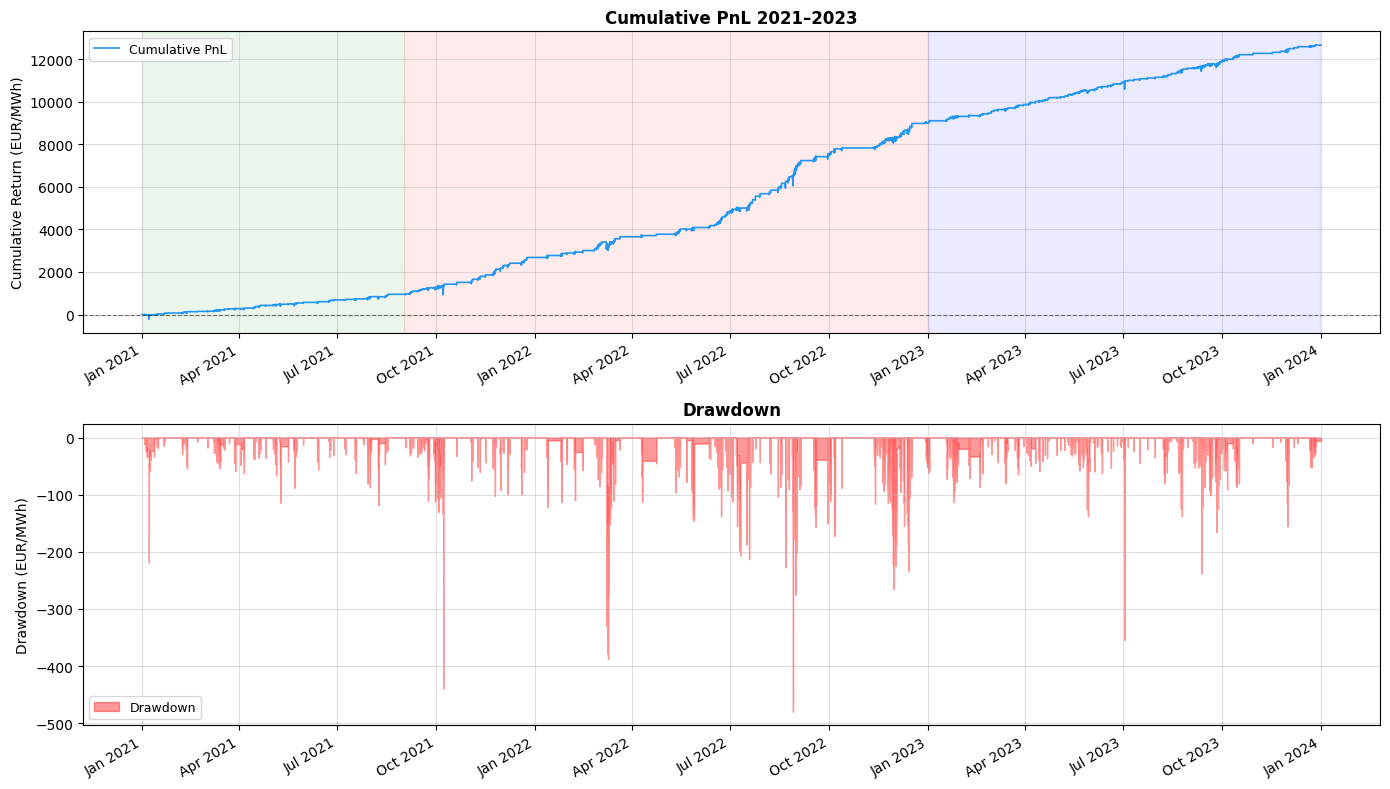

Chart saved.


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Top chart: Cumulative PnL full period ─────────────────────────
ax1 = axes[0]
ax1.plot(df["price_timestamp"], df["cumulative_pnl"],
         color="#2196F3", linewidth=1.2, label="Cumulative PnL")

# Shade regimes
ax1.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-09-01"),
            alpha=0.08, color="green")
ax1.axvspan(pd.Timestamp("2021-09-01"), pd.Timestamp("2023-01-01"),
            alpha=0.08, color="red")
ax1.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"),
            alpha=0.08, color="blue")

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax1.set_title("Cumulative PnL 2021–2023", fontsize=12, fontweight="bold")
ax1.set_ylabel("Cumulative Return (EUR/MWh)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# ── Bottom chart: Drawdown ────────────────────────────────────────
ax2 = axes[1]
rolling_max = df["cumulative_pnl"].cummax()
drawdown    = df["cumulative_pnl"] - rolling_max

ax2.fill_between(df["price_timestamp"], drawdown, 0,
                 color="red", alpha=0.4, label="Drawdown")
ax2.set_title("Drawdown", fontsize=12, fontweight="bold")
ax2.set_ylabel("Drawdown (EUR/MWh)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("spark_spread_project/data/clean/04_cumulative_pnl.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")